In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.autograd as autograd
import torch.optim as optim
import torch.nn.functional as F

In [46]:
!pip install scikit-learn

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if(torch.cuda.is_available()):
    print(f"GPU available: {torch.cuda.get_device_name()}")
    gpu = True
else:
    print("No GPU available")

GPU available: NVIDIA GeForce RTX 5050 Laptop GPU


In [48]:
matches_path = "data/Matches.csv"

df = pd.read_csv(matches_path)
print(df.shape)

(230557, 48)


/tmp/ipykernel_157961/4087795544.py:3: DtypeWarning: Columns (0: MatchTime) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(matches_path)


In [49]:
features_to_drop = [
    'HTHome', 'HTAway', 'HTResult',    
    'OddHome', 'OddDraw', 'OddAway', 'MaxHome', 'MaxDraw', 'MaxAway', 
    'Over25', 'Under25', 'MaxOver25', 'MaxUnder25', 
    'HandiSize', 'HandiHome', 'HandiAway', 
    'C_LTH', 'C_LTA', 'C_VHD', 'C_VAD', 'C_HTB', 'C_PHB',    
]

thin_df = df.drop(features_to_drop, axis="columns")
thin_df = thin_df.dropna()
print(thin_df.shape)
thin_df.info()

(31463, 26)
<class 'pandas.DataFrame'>
Index: 31463 entries, 162577 to 230556
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Division     31463 non-null  str    
 1   MatchDate    31463 non-null  str    
 2   MatchTime    31463 non-null  str    
 3   HomeTeam     31463 non-null  str    
 4   AwayTeam     31463 non-null  str    
 5   HomeElo      31463 non-null  float64
 6   AwayElo      31463 non-null  float64
 7   Form3Home    31463 non-null  float64
 8   Form5Home    31463 non-null  float64
 9   Form3Away    31463 non-null  float64
 10  Form5Away    31463 non-null  float64
 11  FTHome       31463 non-null  float64
 12  FTAway       31463 non-null  float64
 13  FTResult     31463 non-null  str    
 14  HomeShots    31463 non-null  float64
 15  AwayShots    31463 non-null  float64
 16  HomeTarget   31463 non-null  float64
 17  AwayTarget   31463 non-null  float64
 18  HomeFouls    31463 non-null  float64
 19  Aw

### Compute Attacking and Correctness Coefficients

Coefficients based on the following metrics:
- **Pericolosity:** the amount of offensive game created considering the number of corners, shots, shots on target and goals (weighted).
- **Correctness:** the amount of infractions committed considering the number of fouls, yellow and red cards (weighted) by a team.

In [50]:
thin_df['AttackingCoefficientHome'] = 1*thin_df["HomeCorners"] + 3*thin_df['HomeShots'] + 5*thin_df['HomeTarget'] + 10*thin_df['FTHome']  
thin_df['AttackingCoefficientAway'] = 1*thin_df["AwayCorners"] + 3*thin_df['AwayShots'] + 5*thin_df['AwayTarget'] + 10*thin_df['FTAway']

thin_df['CorrectnessCoefficientHome'] = 1*thin_df["HomeFouls"] + 5*thin_df['HomeYellow'] + 15*thin_df['HomeRed']
thin_df['CorrectnessCoefficientAway'] = 1*thin_df["AwayFouls"] + 5*thin_df['AwayYellow'] + 15*thin_df['AwayRed']
thin_df = thin_df.drop(columns=["HomeFouls", "HomeYellow", "HomeRed", "AwayFouls", "AwayYellow", "AwayRed", "HomeCorners", "AwayCorners"])
thin_df.info()

<class 'pandas.DataFrame'>
Index: 31463 entries, 162577 to 230556
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Division                    31463 non-null  str    
 1   MatchDate                   31463 non-null  str    
 2   MatchTime                   31463 non-null  str    
 3   HomeTeam                    31463 non-null  str    
 4   AwayTeam                    31463 non-null  str    
 5   HomeElo                     31463 non-null  float64
 6   AwayElo                     31463 non-null  float64
 7   Form3Home                   31463 non-null  float64
 8   Form5Home                   31463 non-null  float64
 9   Form3Away                   31463 non-null  float64
 10  Form5Away                   31463 non-null  float64
 11  FTHome                      31463 non-null  float64
 12  FTAway                      31463 non-null  float64
 13  FTResult                    31463 non-nul

In [51]:
def compute_avg(df, group_ft, feature, n = 5):
    """
        INPUT:
            df: dataframe,
            group_ft: feature that groups the samples for the avg,
            feature: feature to compute the avarage of
            n: consecutive values to consider for the avg
    """
    avg = df.groupby(group_ft)[feature].shift(1).rolling(window=n, min_periods=1).mean()
    return avg

df_home = thin_df[["MatchDate", "HomeTeam", "HomeShots", "FTHome", "FTAway", "HomeTarget"]].copy()
df_home = df_home.rename(columns={
    'HomeTeam': 'team',
    'FTHome': 'goals',
    'HomeShots': 'shots',
    'HomeTarget': 'target',
    'FTAway': 'conceded',
    'AttackingCoefficientHome': 'pericolosity',
    'CorrectnessCoefficientHome': 'correctness'
})

df_away = thin_df[["MatchDate", "AwayTeam", "AwayShots", "FTAway", "FTHome", "AwayTarget", "AttackingCoefficientAway", "CorrectnessCoefficientAway"]].copy()    
df_away = df_away.rename(columns={
    'AwayTeam': 'team',
    'FTAway': 'goals',
    'AwayShots': 'shots',
    'AwayTarget': 'target',
    'FTHome': 'conceded',
    'AttackingCoefficientAway': 'pericolosity',
    'CorrectnessCoefficientAway': 'correctness'
})

cat_df = pd.concat([df_home, df_away])

# at this point in cat_df we have the list matches for teams grouped by and sorted
cat_df = cat_df.sort_values(by=['team', 'MatchDate'])
cat_df.info()

<class 'pandas.DataFrame'>
Index: 62926 entries, 172290 to 230426
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MatchDate     62926 non-null  str    
 1   team          62926 non-null  str    
 2   shots         62926 non-null  float64
 3   goals         62926 non-null  float64
 4   conceded      62926 non-null  float64
 5   target        62926 non-null  float64
 6   pericolosity  31463 non-null  float64
 7   correctness   31463 non-null  float64
dtypes: float64(6), str(2)
memory usage: 4.3 MB


In [52]:
cat_df['Form5Shots'] = compute_avg(cat_df, 'team', 'shots')
cat_df['Form5Target'] = compute_avg(cat_df, 'team', 'target')
cat_df['Form5Goals'] = compute_avg(cat_df, 'team', 'goals')
cat_df['Form5GoalsConceded'] = compute_avg(cat_df, 'team', 'conceded')
cat_df['Form5Pericolosity'] = compute_avg(cat_df, 'team', 'pericolosity')
cat_df['Form5Correctness'] = compute_avg(cat_df, 'team', 'correctness')

thin_df = thin_df.merge(
    cat_df,
    left_on=['MatchDate', 'HomeTeam'],
    right_on=['MatchDate', 'team'],
    how='left'
)

thin_df = thin_df.rename(columns={
    'Form5Shots': 'Form5ShotsHome',
    'Form5Target': 'Form5TargetHome',
    'Form5Goals': 'Form5GoalsHome',
    'Form5GoalsConceded': 'Form5GoalsConcededHome',
    'Form5Pericolosity': 'Form5PericolosityHome',
    'Form5Correctness': 'Form5CorrectnessHome'
    })
thin_df = thin_df.drop(columns=['team', 'goals', 'shots', 'target', 'conceded', 'pericolosity', 'correctness'])

thin_df = thin_df.merge(
    cat_df,
    left_on=['MatchDate', 'AwayTeam'],
    right_on=['MatchDate', 'team'],
    how='left'
)

thin_df = thin_df.rename(columns={
    'Form5Shots': 'Form5ShotsAway',
    'Form5Target': 'Form5TargetAway',
    'Form5Goals': 'Form5GoalsAway',
    'Form5GoalsConceded': 'Form5GoalsConcededAway',
    'Form5Pericolosity': 'Form5PericolosityAway',
    'Form5Correctness': 'Form5CorrectnessAway'
})
thin_df = thin_df.drop(columns=['team', 'goals', 'shots', 'target', 'conceded', 'pericolosity', 'correctness'])

In [53]:
drop_columns = [
    'HomeShots', 'AwayShots', 'HomeTarget', 'AwayTarget', 'FTHome', 'FTAway',
    'AttackingCoefficientHome', 'AttackingCoefficientAway',
    'CorrectnessCoefficientHome', 'CorrectnessCoefficientAway'
]

thin_df = thin_df.drop(columns=drop_columns)


In [54]:
df = thin_df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 31451 entries, 0 to 31462
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Division                31451 non-null  str    
 1   MatchDate               31451 non-null  str    
 2   MatchTime               31451 non-null  str    
 3   HomeTeam                31451 non-null  str    
 4   AwayTeam                31451 non-null  str    
 5   HomeElo                 31451 non-null  float64
 6   AwayElo                 31451 non-null  float64
 7   Form3Home               31451 non-null  float64
 8   Form5Home               31451 non-null  float64
 9   Form3Away               31451 non-null  float64
 10  Form5Away               31451 non-null  float64
 11  FTResult                31451 non-null  str    
 12  Form5ShotsHome          31451 non-null  float64
 13  Form5TargetHome         31451 non-null  float64
 14  Form5GoalsHome          31451 non-null  float64
 15  F

In [55]:
df["Form3Difference"] = df["Form3Home"] - df["Form3Away"]
df["Form5Difference"] = df["Form5Home"] - df["Form5Away"]

In [56]:
# make the 'date' and 'time' feature as int values that we store in our dataframe.
date_parts = df.iloc[:, 1].str.split("-", expand=True)

df['Year'] = date_parts[0].astype('int16')
df['Month'] = date_parts[1].astype('int16')
df['Day'] = date_parts[2].astype('int16')

time_parts = df.iloc[:, 2].str.split(":", expand=True)

df['Hour'] = time_parts[0].astype('int8')
df['Minutes'] = time_parts[1].astype('int8')

# in the end we drop the previous features stored as strings.
df_min = df.drop(columns=["MatchDate", "MatchTime", "HomeTeam", "AwayTeam", "Division"])

In [57]:
# define an array of unique team names' string.
unique_teams = [x for x in df['HomeTeam'].unique()]

print(unique_teams)
print(len(unique_teams))

['Ajaccio', 'Chambly', 'Clermont', 'Guingamp', 'Nancy', 'Niort', 'Rodez', 'Sochaux', 'Genk', 'Stuttgart', 'Dresden', 'Le Mans', 'Holstein Kiel', 'Osnabruck', 'Cercle Brugge', 'St Truiden', 'Waregem', 'Hamburg', 'Anderlecht', 'Greuther Furth', 'Regensburg', 'Wehen', 'Charleroi', 'Eupen', 'Bielefeld', 'Lorient', 'Bochum', 'Sandhausen', 'Auxerre', 'Chateauroux', 'Grenoble', 'Le Havre', 'Orleans', 'Paris FC', 'Troyes', 'Valenciennes', 'Zwolle', 'St Pauli', 'Club Brugge', 'Luton', 'Karlsruhe', 'Hannover', 'Celtic', 'Hibernian', 'Livingston', 'Ross County', 'Barnsley', 'Blackburn', 'Brentford', 'Millwall', 'Reading', 'Stoke', 'Swansea', 'Wigan', 'Lens', 'Standard', 'FC Emmen', 'Vitesse', 'Nottm Forest', 'Kortrijk', 'Oostende', 'Mechelen', 'Twente', 'VVV Venlo', 'Heracles', 'Heidenheim', 'Kilmarnock', 'Gent', 'Feyenoord', 'Darmstadt', 'Erzgebirge Aue', 'Aberdeen', 'Den Haag', 'Bristol City', 'Mouscron', 'AZ Alkmaar', 'Nurnberg', 'Huddersfield', 'Caen', 'Sparta Rotterdam', 'Monaco', 'Liverpool

In [58]:
# code taken from the https://gist.github.com/GavinXing/9954ea846072e115bb07d9758892382c
# so far we are not using it since for simplicity we drop the TeamNames columns from the dataset

class CBOW(nn.Module):

    def __init__(self, context_size=2, embedding_size=100, vocab_size=None):
        super(CBOW, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_size)
        self.linear1 = nn.Linear(embedding_size, vocab_size)

    def forward(self, inputs):
        lookup_embeds = self.embeddings(inputs)
        embeds = lookup_embeds.sum(dim=0)
        out = self.linear1(embeds)
        out = F.log_softmax(out)
        return out
    
def make_context_vector(context, word_to_ix):
    idxs = [word_to_ix[w] for w in context]
    tensor = torch.LongTensor(idxs)
    return autograd.Variable(tensor)

In [59]:
vocab = set(unique_teams)
vocab_size = len(vocab)

word_to_ix = {word: i for i, word in enumerate(vocab)}
data = []

In [60]:
result_mapping = {'H': 0, 'D': 1, 'A': 2}
df_min['Target'] = df_min['FTResult'].map(result_mapping).astype('int8')

df_min = df_min.drop(columns=["FTResult"])
df_min.info()

<class 'pandas.DataFrame'>
Index: 31451 entries, 0 to 31462
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   HomeElo                 31451 non-null  float64
 1   AwayElo                 31451 non-null  float64
 2   Form3Home               31451 non-null  float64
 3   Form5Home               31451 non-null  float64
 4   Form3Away               31451 non-null  float64
 5   Form5Away               31451 non-null  float64
 6   Form5ShotsHome          31451 non-null  float64
 7   Form5TargetHome         31451 non-null  float64
 8   Form5GoalsHome          31451 non-null  float64
 9   Form5GoalsConcededHome  31451 non-null  float64
 10  Form5PericolosityHome   31451 non-null  float64
 11  Form5CorrectnessHome    31451 non-null  float64
 12  Form5ShotsAway          31451 non-null  float64
 13  Form5TargetAway         31451 non-null  float64
 14  Form5GoalsAway          31451 non-null  float64
 15  F

In [61]:
df_min

,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,Form5Away,Form5ShotsHome,Form5TargetHome,Form5GoalsHome,Form5GoalsConcededHome,...,Form5PericolosityAway,Form5CorrectnessAway,Form3Difference,Form5Difference,Year,Month,Day,Hour,Minutes,Target
0,1360.18,1438.67,4.0,4.0,1.0,4.0,10.25,3.75,0.75,3.50,...,68.0,36.5,3.0,0.0,2019,7,26,19,0,1
1,1315.69,1361.10,0.0,0.0,4.0,5.0,10.00,3.00,0.75,1.50,...,69.5,18.0,-4.0,-5.0,2019,7,26,19,0,0
2,1414.77,1396.05,1.0,3.0,7.0,11.0,14.75,3.50,1.25,1.25,...,47.0,25.0,-6.0,-8.0,2019,7,26,19,0,0
3,1471.61,1364.04,2.0,3.0,1.0,5.0,18.50,5.00,1.50,1.50,...,66.5,29.0,1.0,-2.0,2019,7,26,19,0,1
4,1364.51,1380.99,3.0,9.0,1.0,1.0,17.00,4.25,1.25,2.25,...,55.0,17.0,2.0,8.0,2019,7,26,19,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31458,1339.21,1544.15,3.0,6.0,7.0,13.0,6.60,2.80,1.40,1.80,...,74.5,18.5,-4.0,-7.0,2025,6,1,17,30,2
31459,1544.16,1433.67,4.0,10.0,1.0,3.0,14.80,5.00,2.00,0.60,...,49.0,45.5,3.0,7.0,2025,6,1,17,30,0
31460,1473.67,1569.98,0.0,3.0,3.0,7.0,12.60,3.20,1.80,1.80,...,51.0,37.0,-3.0,-4.0,2025,6,1,17,30,2
31461,1574.90,1525.76,7.0,13.0,6.0,9.0,9.60,2.80,1.20,0.40,...,42.5,30.0,1.0,4.0,2025,6,1,17,30,0


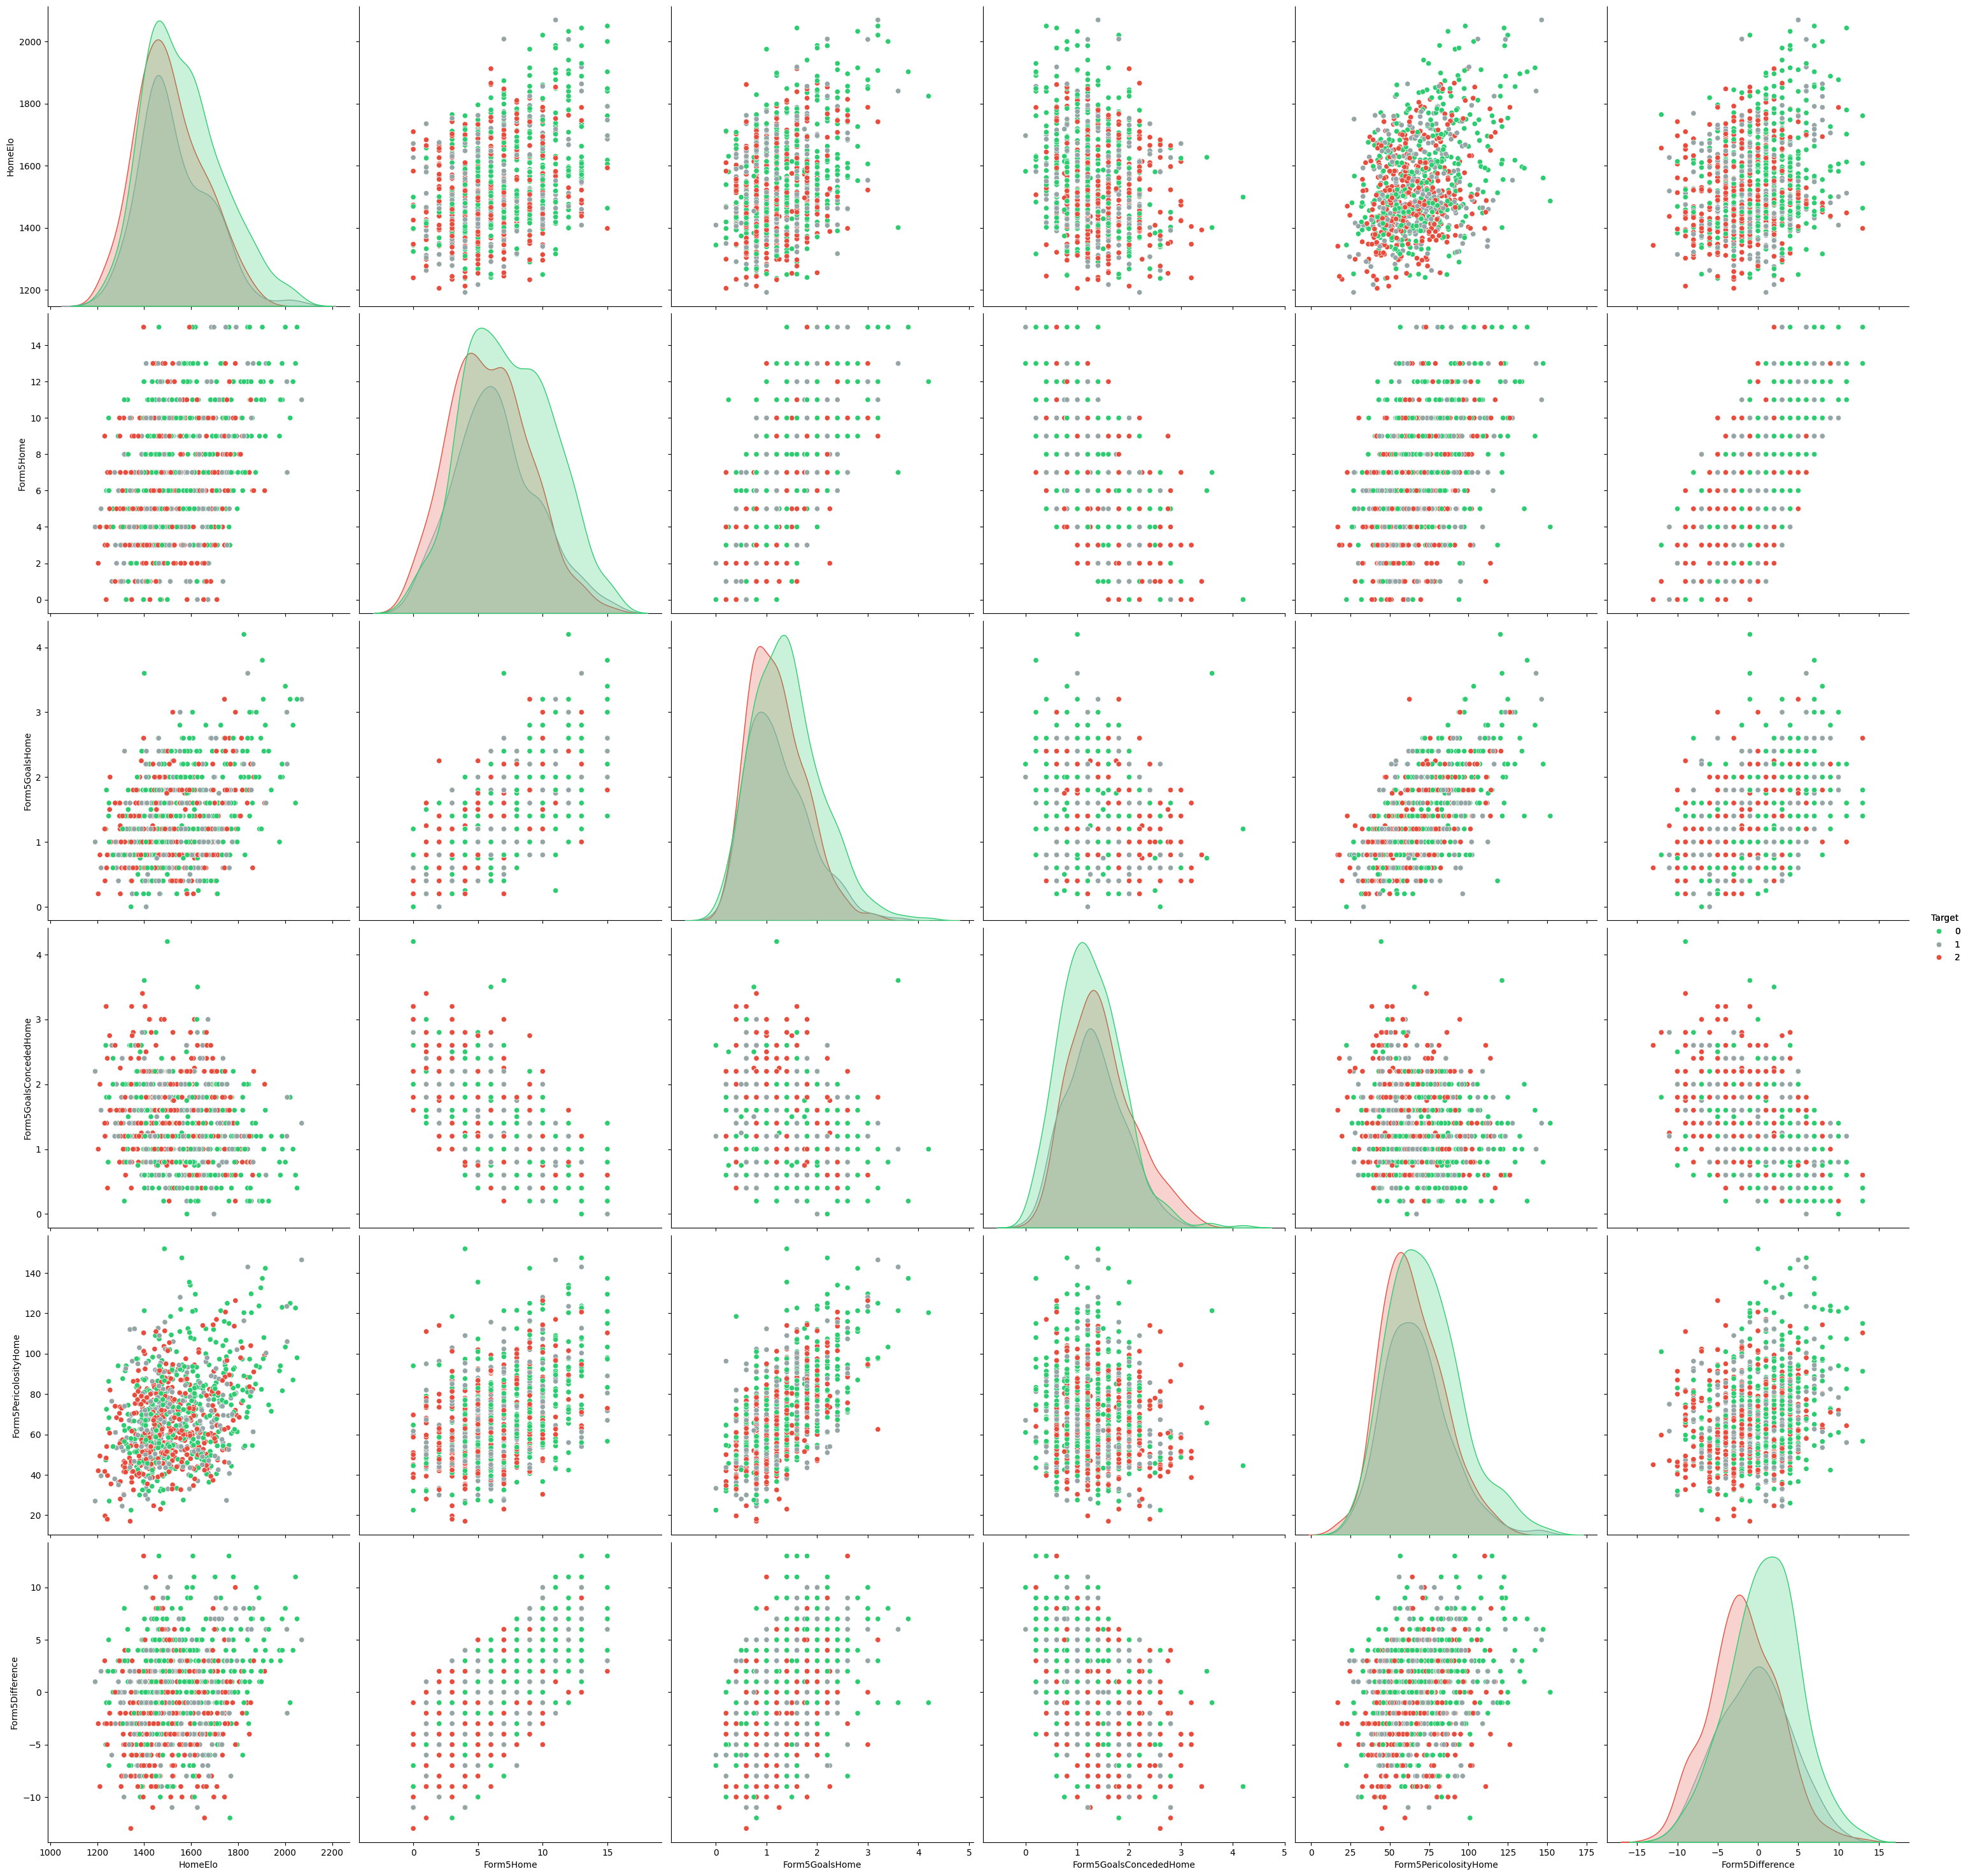

In [68]:
import seaborn as sns

cols_relation = [
    'HomeElo', 'Form5Home', 'Form5GoalsHome', 'Form5GoalsConcededHome', 'Form5PericolosityHome', 'Form5Difference'
]
random_df = df_min.sample(1000)

sns.pairplot(random_df, x_vars=cols_relation, y_vars=cols_relation, hue="Target", palette=['#2ecc71', '#95a5a6', '#e74c3c'], height=5).add_legend()

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

num_features = df_min.shape[1] - 1
print(num_features)

y_labels = df_min.iloc[:, num_features]
X_features = df_min.drop(df_min.columns[num_features], axis=1)

25


In [ ]:
from sklearn.model_selection import train_test_split
X, X_test, y, y_test = train_test_split(
    X_features, y_labels, test_size=0.20, random_state=42, shuffle=False
)

X_train, x_eval, y_train, y_eval = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print(X_train.shape)
print(x_eval.shape)
print(X_test.shape)

(20128, 25)
(5032, 25)
(6291, 25)


In [ ]:
scaler = StandardScaler()

# scale data based on the mean and std of the training data
X_train = scaler.fit_transform(X_train) # computes mean and std of training set
X_test = scaler.transform(X_test)
x_eval = scaler.transform(x_eval)

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.long)

X_eval = torch.tensor(x_eval, dtype=torch.float32)
y_eval = torch.tensor(y_eval.values, dtype=torch.long)

train_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=False)
test_dataloader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)
eval_dataloader = DataLoader(TensorDataset(X_eval, y_eval), batch_size=64, shuffle=False)


### Model Definition

In [ ]:
class ModelClassifier(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        
        self.lin1 = nn.Linear(num_features, out_features=64) # linear applies x * W^T + b
        self.lin2 = nn.Linear(64, out_features=16)
        self.output_layer = nn.Linear(16, out_features=3) # output layer
        
        self.hidden_act = nn.LeakyReLU()
        # self.output_act = nn.Softmax() # defines the SoftMax behaviour for more than 2 classes classification
        self.dropout = nn.Dropout(p=0.3)
        
    def forward(self, x):        
        # activation of the first layer
        x = self.lin1(x)
        x = self.hidden_act(x)
        x = self.dropout(x)
        
        # activation of the second layer
        x = self.lin2(x)
        x = self.hidden_act(x)
        x = self.dropout(x)
        
        x = self.output_layer(x)        
        return x

Define some usefull elements for the training like:
- Initialize the model;
- Initialize hyperparameters (learning rate, weight decay);
- Initialize Optimizers;

In [ ]:
EPOCHS = 100
EPOCHS_STOP = 5

lr = 1e-01
weight_decay = 0
weight_result = False
weights = torch.tensor([1.0, 1.25, 1.1]).to(device) if weight_result else None

model = ModelClassifier(num_features=num_features)
criterion = nn.CrossEntropyLoss(weight=weights) # adding weights in order to make some predictions more predictable (model never predicts 1 so far)
model.to(device)
model.train()

optimizer = optim.SGD(
    model.parameters(),
    lr=lr,
    weight_decay=0,
)
lr_scheduler = optim.lr_scheduler.MultiplicativeLR(
    optimizer=optimizer,
    lr_lambda= lambda epoch: 0.95
)

### EVAL FUNCTION 

In [ ]:
def eval_model(model, dataloader, loss_fn, device):
    """
        Function that validates the model
        INPUTS:
            - model: our defined class model;
            - dataloader: an instance of the validation dataloader containing samples and labels;
            - loss_fn: loss function (just for health checking the results);
            - device: gpu or cpu boolean value.
    """
    
    model.eval()  # Set to evaluation mode

    total_loss = 0
    correct = 0
    samples = 0
    metrics = {} # further implementation
    
    with torch.no_grad():
        for input_batch, label_batch in dataloader:
            input_batch = input_batch.to(device)
            label_batch = label_batch.to(device)
            
            label_batch = label_batch.long()
            
            predict = model(input_batch)
            
            loss = loss_fn(predict, label_batch)
            
            total_loss += loss.item()
            predictions = torch.argmax(predict, dim=1)
            correct += (predictions == label_batch).sum().item() # add up the number of correct training predictions
            samples += label_batch.size(0) # Add batch size (e.g., 32)
            
                
    model.train()  # Set back to training mode
    metrics["Avg_loss"] = total_loss / len(dataloader)
    metrics["Accuracy"] = correct / samples
    
    return metrics

### TRAINING

In [ ]:
#model = ModelClassifier(num_features=num_features)
#model.train(True)
train_loss = []
eval_loss = []


# set these values for the early stopping
best_loss = float('inf')
count = 0
for epoch in range(EPOCHS):
    total_loss = 0
    correct = 0
    for input_batch, label_batch in train_dataloader:
        input_batch = input_batch.to(device)
        label_batch = label_batch.to(device)
        
        label_batch = label_batch.long()
        
        logits = model(input_batch)
        
        # zero-out the gradients
        optimizer.zero_grad()
        loss = criterion(logits, label_batch)
        
        loss.backward() # perform backpropagation
        
        # compute the next step for the optimizer and the lr_scheduler
        optimizer.step()
        
        # compute total training loss and correct predictions
        total_loss += loss.item()
        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == label_batch).sum().item() # add up the number of correct training predictions
                
    metrics = eval_model(model, eval_dataloader, criterion, device=device)
    lr_scheduler.step()
    
    if epoch % 10 == 0:
        print(f"Loss for epoch nr. {epoch + 1}: {total_loss:.2f}")
        print(f"Correct predictions for epoch nr. {epoch + 1}: {correct}\n")
        
        #for logit, label in zip(logits, label_batch):
        #    prediction = F.softmax(logit, dim=0)
        #    print(f"Our prediction: {prediction}")
        #    print(f"True prediction: {label}")
        print(f"Eval Loss for epoch nr. {epoch + 1}: {metrics["Avg_loss"]:.2f}")
        print(f"Eval percentage of correct predictions for epoch nr. {epoch + 1}: {metrics["Accuracy"]*100:.2f}\n")
    
    train_loss.append(total_loss) # append loss relative to the epoch
    eval_loss.append(metrics["Avg_loss"])
        
    if total_loss < best_loss:
        best_loss = total_loss
        count = 0 # reset the count because we improved the loss
    else:
        count += 1
        
    # if count == EPOCHS_STOP:
    #     print(f"Early stopping at epoch nr. {epoch + 1}")
    #     break # we stop the training if we have no improvement   
    
print(logits)
print(predictions)
print(label_batch)

mean_train_loss = np.mean(train_loss)
mean_eval_loss = np.mean(eval_loss)
print(f"Mean train loss: {mean_train_loss:.4f}")
print(f"Mean eval loss: {mean_eval_loss:.4f}")
    

Loss for epoch nr. 1: 330.73
Correct predictions for epoch nr. 1: 9287

Eval Loss for epoch nr. 1: 1.02
Eval percentage of correct predictions for epoch nr. 1: 49.90

Loss for epoch nr. 11: 319.66
Correct predictions for epoch nr. 11: 9974

Eval Loss for epoch nr. 11: 1.00
Eval percentage of correct predictions for epoch nr. 11: 51.15

Loss for epoch nr. 21: 319.10
Correct predictions for epoch nr. 21: 9958

Eval Loss for epoch nr. 21: 1.00
Eval percentage of correct predictions for epoch nr. 21: 51.01

Loss for epoch nr. 31: 318.23
Correct predictions for epoch nr. 31: 9985

Eval Loss for epoch nr. 31: 1.00
Eval percentage of correct predictions for epoch nr. 31: 51.05

Loss for epoch nr. 41: 317.85
Correct predictions for epoch nr. 41: 9979

Eval Loss for epoch nr. 41: 1.00
Eval percentage of correct predictions for epoch nr. 41: 51.05

Loss for epoch nr. 51: 317.71
Correct predictions for epoch nr. 51: 10101

Eval Loss for epoch nr. 51: 1.00
Eval percentage of correct predictions fo